# 04 — Linear Multivariate Analysis — CAMS Air Quality × Health

Two-stage approach:
1. **Correlation screening** — Spearman cross-correlation functions (CCF) at lags 0–7 days, computed on the full pooled time series (no per-year splitting; `year` enters as a continuous linear trend in regression only)
2. **Regression models** — Negative Binomial GLM for count outcomes, OLS + HAC for response times; distributed lag structure; FDR-corrected results

**This run uses CAMS data only** (PM2.5, PM10, NO₂, O₃, SO₂).  
**COVID period excluded** (2020-03-15 → 2021-06-30) — rows removed, not flagged.

**Spatial levels**:
- A: City-wide temporal (pooled 2018–2023, COVID removed)
- B: District-level fixed-effects panel (12 districts × analysis days)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from scipy import stats
from statsmodels.regression.linear_model import OLS
from statsmodels.stats.sandwich_covariance import cov_hac
from statsmodels.genmod.generalized_linear_model import GLM
from statsmodels.genmod import families
from statsmodels.tools import add_constant
from statsmodels.stats.multitest import multipletests

PROC_DIR = Path('../data/processed')

print('Libraries loaded')

Libraries loaded


In [3]:
# ── Load preprocessed CAMS daily means (2025) ────────────────────────────────
# City-wide CSV already contains 22 AQ vars + lag_1…lag_7 for 9 core vars
cams_df = pd.read_csv(PROC_DIR / 'cams_daily_2025.csv', parse_dates=['date'])
print(f'CAMS city-wide: {cams_df.shape}  |  {cams_df.date.min().date()} → {cams_df.date.max().date()}')

# ── Load health data, filter to 2025, merge ───────────────────────────────────
health_df = pd.read_csv(PROC_DIR / 'daily_city_health.csv', parse_dates=['date'])
health_df = health_df[health_df['date'].dt.year == 2025].reset_index(drop=True)

df = health_df.merge(cams_df, on='date', how='inner')
df = df.sort_values('date').reset_index(drop=True)

print(f'Health 2025:    {health_df.shape[0]} days')
print(f'After merge:    {df.shape}  |  {df.date.min().date()} → {df.date.max().date()}')
print(f'AQ vars in df:  {[c for c in ["pm25","pm10","no2","o3","so2"] if c in df.columns]}')

CAMS city-wide: (365, 86)  |  2025-01-01 → 2025-12-31
Health 2025:    365 days
After merge:    (365, 135)  |  2025-01-01 → 2025-12-31
AQ vars in df:  ['pm25', 'pm10', 'no2', 'o3', 'so2']


## 1. Define Variable Sets

In [4]:
# Health outcome columns
HEALTH_CODES = [
    'code_06_breathing', 'code_31_loss_of_consciousness', 'code_17_falls',
    'code_09_cardiac_arrest', 'code_10_chest_pain', 'code_19_heart_problems',
    'code_28_stroke_tia', 'code_12_seizure', 'code_20_heat_cold_exposure',
    'code_02_allergy_insect', 'code_13_blood_sugar', 'code_18_headache',
]
NEGATIVE_CONTROLS = ['ctrl_04_assault', 'ctrl_27_stabbing_gunshot',
                     'ctrl_29_traffic_accident', 'ctrl_30_injuries_trauma']
AGGREGATE_EMS = ['mission_count_ems', 'mission_count_ems_critical',
                 'mission_count_ems_critical_cpr']
RESPONSE_TIME = ['response_time_ems_critical_mean']

# CAMS AQ predictors — instantaneous + prebuilt 1–7 day lags from CSV
CLIMATE_CANDIDATES = (
    ['pm25', 'pm10', 'no2', 'o3', 'so2'] +
    [f'{v}_lag{l}' for v in ['pm25', 'no2', 'o3', 'pm10', 'so2'] for l in range(1, 8)]
)
CLIMATE_VARS = [c for c in CLIMATE_CANDIDATES if c in df.columns]

# Confounders — no year trend (single year 2025), no covid_flag needed
CONFOUNDERS = ['day_of_week', 'is_weekend', 'is_public_holiday', 'doy_sin', 'doy_cos', 'month']
CONFOUNDERS = [c for c in CONFOUNDERS if c in df.columns]

HEALTH_CODES      = [c for c in HEALTH_CODES      if c in df.columns]
AGGREGATE_EMS     = [c for c in AGGREGATE_EMS     if c in df.columns]
RESPONSE_TIME     = [c for c in RESPONSE_TIME     if c in df.columns]
NEGATIVE_CONTROLS = [c for c in NEGATIVE_CONTROLS if c in df.columns]

# Core (non-lagged) predictors used in main regression
PRIMARY_CLIMATE = [v for v in ['pm25', 'pm10', 'no2', 'o3', 'so2'] if v in df.columns]

print(f'AQ climate vars ({len(CLIMATE_VARS)}): instantaneous + lag1–7')
print(f'Primary (no lag): {PRIMARY_CLIMATE}')
print(f'Health outcomes:  {len(HEALTH_CODES)}')
print(f'Confounders:      {CONFOUNDERS}')

AQ climate vars (40): instantaneous + lag1–7
Primary (no lag): ['pm25', 'pm10', 'no2', 'o3', 'so2']
Health outcomes:  12
Confounders:      ['day_of_week', 'is_weekend', 'is_public_holiday', 'doy_sin', 'doy_cos', 'month']


## 2. Correlation Screening — Spearman CCF at Lags 0–14 Days

For each (climate variable, health outcome) pair, compute Spearman correlation at lag 0 through 14. This reveals:
- Which climate variables have the strongest signal
- At what lag the effect peaks
- Whether the signal disappears for negative controls (model validation)

In [5]:
def spearman_ccf(df, climate_var, outcome_var, max_lag=7):
    """Compute Spearman r between lagged climate variable and outcome.
    
    Uses the full pooled time series — no per-year stratification.
    The annual seasonal cycle is controlled in regression via doy_sin/doy_cos;
    CCF here shows raw lagged association across all years combined.
    """
    results = []
    y = df[outcome_var]
    for lag in range(0, max_lag + 1):
        x = df[climate_var].shift(lag)
        mask = x.notna() & y.notna()
        if mask.sum() < 100:
            results.append({'lag': lag, 'r': np.nan, 'p': np.nan})
            continue
        r, p = stats.spearmanr(x[mask], y[mask])
        results.append({'lag': lag, 'r': r, 'p': p})
    return pd.DataFrame(results)

# Sample: pm25 → breathing difficulties
if 'pm25' in CLIMATE_VARS and 'code_06_breathing' in df.columns:
    print('Sample CCF: pm25 → code_06_breathing (lags 0–7):')
    sample = spearman_ccf(df, 'pm25', 'code_06_breathing', max_lag=7)
    print(sample.to_string(index=False))

Sample CCF: pm25 → code_06_breathing (lags 0–7):
 lag        r            p
   0 0.381802 4.108749e-14
   1 0.417174 9.260016e-17
   2 0.402700 1.386166e-15
   3 0.372449 2.351826e-13
   4 0.367156 5.807006e-13
   5 0.377822 1.165996e-13
   6 0.355402 3.970547e-12
   7 0.342013 2.927776e-11


In [6]:
# Build full CCF matrix: peak correlation (max |r| across lags 0–7) for each pair
if len(CLIMATE_VARS) > 0:
    MAX_LAG = 7
    peak_r   = pd.DataFrame(index=CLIMATE_VARS, columns=HEALTH_CODES + NEGATIVE_CONTROLS, dtype=float)
    peak_lag = pd.DataFrame(index=CLIMATE_VARS, columns=HEALTH_CODES + NEGATIVE_CONTROLS, dtype=int)

    for cv in CLIMATE_VARS:
        for hc in HEALTH_CODES + NEGATIVE_CONTROLS:
            if hc not in df.columns:
                continue
            ccf = spearman_ccf(df, cv, hc, max_lag=MAX_LAG)
            best = ccf.iloc[ccf['r'].abs().idxmax()]
            peak_r.loc[cv, hc]   = best['r']
            peak_lag.loc[cv, hc] = int(best['lag'])

    print('Peak Spearman r matrix (rows=climate, cols=health):')
    print(peak_r.round(3).to_string())

Peak Spearman r matrix (rows=climate, cols=health):
           code_06_breathing  code_31_loss_of_consciousness  code_17_falls  code_09_cardiac_arrest  code_10_chest_pain  code_19_heart_problems  code_28_stroke_tia  code_12_seizure  code_20_heat_cold_exposure  code_02_allergy_insect  code_13_blood_sugar  code_18_headache  ctrl_04_assault  ctrl_27_stabbing_gunshot  ctrl_29_traffic_accident  ctrl_30_injuries_trauma
pm25                   0.417                          0.154          0.114                   0.226               0.209                   0.046              -0.048            0.079                       0.243                  -0.278                0.172             0.070           -0.126                    -0.127                    -0.240                   -0.276
pm10                   0.325                          0.183          0.122                   0.187               0.140                  -0.081              -0.067            0.082                       0.184           

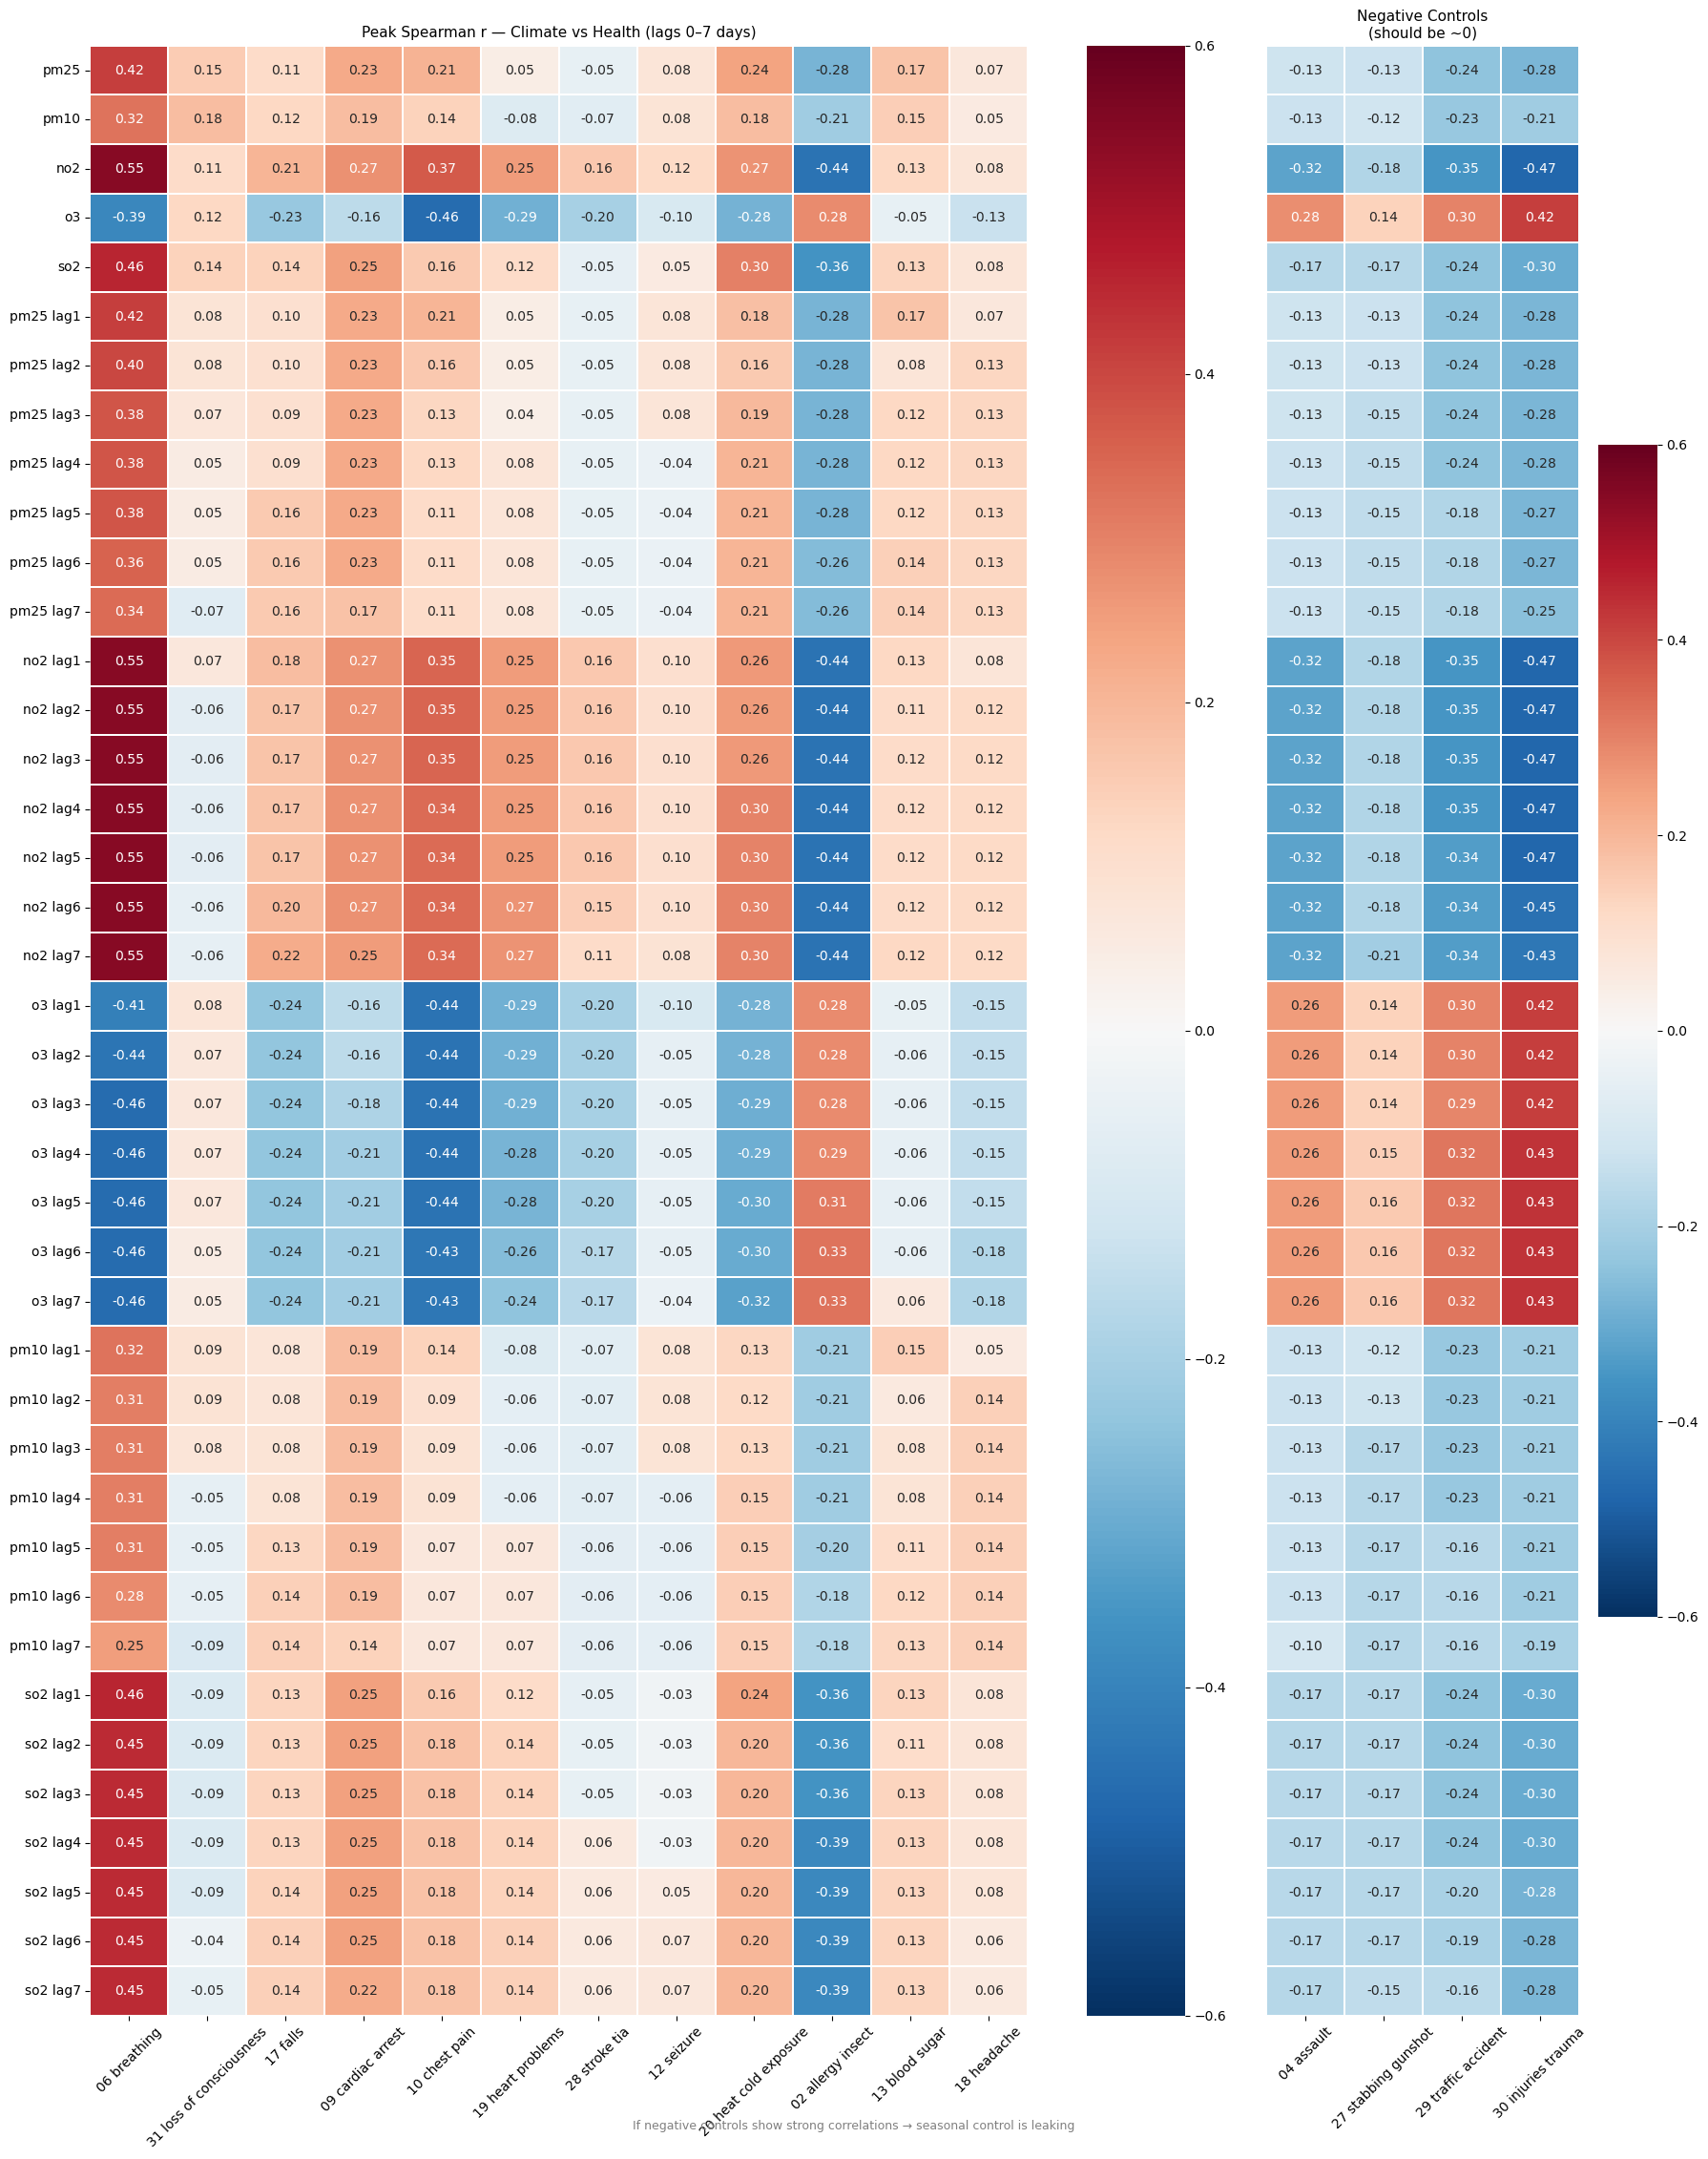

In [7]:
# Heatmap of peak correlations
if len(CLIMATE_VARS) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(18, len(CLIMATE_VARS) * 0.5 + 3),
                              gridspec_kw={'width_ratios': [3, 1]})

    # Climate-sensitive codes
    health_sub  = [c for c in HEALTH_CODES if c in peak_r.columns]
    control_sub = [c for c in NEGATIVE_CONTROLS if c in peak_r.columns]

    short_health  = [c.replace('code_', '').replace('_', ' ') for c in health_sub]
    short_control = [c.replace('ctrl_', '').replace('_', ' ') for c in control_sub]
    short_clim    = [c.replace('_', ' ') for c in CLIMATE_VARS]

    ax = axes[0]
    sns.heatmap(peak_r[health_sub].astype(float), annot=True, fmt='.2f',
                cmap='RdBu_r', center=0, vmin=-0.6, vmax=0.6,
                xticklabels=short_health, yticklabels=short_clim, ax=ax,
                linewidths=0.3)
    ax.set_title('Peak Spearman r — Climate vs Health (lags 0–7 days)', fontsize=11)
    ax.tick_params(axis='x', rotation=45)

    ax = axes[1]
    sns.heatmap(peak_r[control_sub].astype(float), annot=True, fmt='.2f',
                cmap='RdBu_r', center=0, vmin=-0.6, vmax=0.6,
                xticklabels=short_control, yticklabels=[], ax=ax,
                linewidths=0.3)
    ax.set_title('Negative Controls\n(should be ~0)', fontsize=11)
    ax.tick_params(axis='x', rotation=45)

    fig.suptitle('If negative controls show strong correlations → seasonal control is leaking', 
                  fontsize=9, color='gray', y=0.02)
    fig.tight_layout()
    plt.savefig(PROC_DIR / 'ccf_peak_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

## 3. Negative Binomial GLM — Count Outcomes

For each climate-sensitive dispatch code, fit:
```
count ~ climate_var(lag) + doy_sin + doy_cos + day_of_week + is_public_holiday + covid_flag + year
```

We use **Negative Binomial** (not Poisson) because daily EMS counts are overdispersed (variance >> mean). The seasonal spline (doy_sin + doy_cos) absorbs the annual cycle so the climate coefficient reflects day-to-day within-season variation.

In [8]:
def fit_negbin(df, outcome, climate_var, lag=0, confounders=None):
    """
    Fit Negative Binomial GLM:
      outcome ~ climate_var(lag) + confounders

    Climate var is standardised using the GLOBAL mean/std across the full
    analysis period — never per-year — so coefficients are comparable
    across variables and reflect a 1 SD change in the overall distribution.
    """
    if confounders is None:
        confounders = ['doy_sin', 'doy_cos', 'day_of_week',
                       'is_public_holiday', 'year']

    work = df[[outcome] + [climate_var] + confounders].copy()
    work[climate_var] = work[climate_var].shift(lag)
    work = work.dropna()

    # Global standardisation (mean/std over the full pooled dataset)
    cv_mean = work[climate_var].mean()
    cv_std  = work[climate_var].std()
    work[climate_var] = (work[climate_var] - cv_mean) / cv_std

    y = work[outcome].values
    # Cast to float to avoid dtype=object errors from bool/int mixed columns
    X = add_constant(work[[climate_var] + confounders].astype(float))

    try:
        model = GLM(y, X, family=families.NegativeBinomial()).fit(disp=False)
        coef  = model.params[climate_var]
        ci    = model.conf_int().loc[climate_var]
        pval  = model.pvalues[climate_var]
        return {
            'outcome': outcome, 'climate_var': climate_var, 'lag': lag,
            'coef': coef, 'ci_low': ci[0], 'ci_high': ci[1],
            'pval': pval, 'aic': model.aic, 'n': int(len(y)),
            'cv_std': cv_std
        }
    except Exception as e:
        return {
            'outcome': outcome, 'climate_var': climate_var, 'lag': lag,
            'coef': np.nan, 'ci_low': np.nan, 'ci_high': np.nan,
            'pval': np.nan, 'aic': np.nan, 'n': 0, 'cv_std': np.nan,
            'error': str(e)
        }

print('fit_negbin() defined')

fit_negbin() defined


In [9]:
# Primary CAMS predictors (instantaneous vars — not rolling lags, those are tested separately)
PRIMARY_CLIMATE = [v for v in ['pm25', 'pm10', 'no2', 'o3', 'so2'] if v in CLIMATE_VARS]

if len(PRIMARY_CLIMATE) > 0:
    rows = []
    outcomes_to_test = HEALTH_CODES + AGGREGATE_EMS

    for outcome in outcomes_to_test:
        if outcome not in df.columns:
            continue
        for cv in PRIMARY_CLIMATE:
            # Use optimal lag from CCF (capped at 3 for AQ — short biological lag)
            best_lag = 0
            if 'peak_lag' in dir() and cv in peak_lag.index and outcome in peak_lag.columns:
                best_lag = min(int(peak_lag.loc[cv, outcome]), 3)
            result = fit_negbin(df, outcome, cv, lag=best_lag, confounders=CONFOUNDERS)
            rows.append(result)

    results_nb = pd.DataFrame(rows)
    print(f'Total tests: {len(results_nb)}')

    # FDR correction across all tests (Benjamini-Hochberg)
    valid = results_nb['pval'].notna()
    if valid.sum() == 0:
        print('WARNING: all NegBin fits returned NaN p-values — check errors column:')
        if 'error' in results_nb.columns:
            print(results_nb[results_nb['pval'].isna()][['outcome','climate_var','error']].head(5).to_string())
        results_nb['pval_fdr'] = np.nan
        results_nb['significant'] = False
    else:
        _, pvals_fdr, _, _ = multipletests(results_nb.loc[valid, 'pval'], method='fdr_bh')
        results_nb.loc[valid, 'pval_fdr'] = pvals_fdr
        results_nb['significant'] = results_nb['pval_fdr'] < 0.05

    print(f'Valid fits: {valid.sum()} / {len(results_nb)}')
    print(f'Significant after FDR (q<0.05): {results_nb["significant"].sum()}')
    print()
    print('Top associations by |coef| (FDR q<0.05):')
    sig = results_nb[results_nb['significant']].sort_values('coef', key=abs, ascending=False)
    if len(sig) > 0:
        print(sig[['outcome','climate_var','lag','coef','ci_low','ci_high','pval_fdr']].head(15).to_string(index=False))
    else:
        print('No significant associations after FDR correction.')
        print()
        print('All results (sorted by raw pval):')
        print(results_nb.sort_values('pval')[['outcome','climate_var','lag','coef','pval']].head(15).to_string(index=False))

Total tests: 75
Valid fits: 75 / 75
Significant after FDR (q<0.05): 3

Top associations by |coef| (FDR q<0.05):
                   outcome climate_var  lag     coef   ci_low  ci_high  pval_fdr
code_20_heat_cold_exposure         so2    0 0.378954 0.239139 0.518768  0.000008
code_20_heat_cold_exposure         no2    0 0.310407 0.129342 0.491473  0.029224
code_20_heat_cold_exposure        pm10    0 0.217323 0.085326 0.349321  0.031282


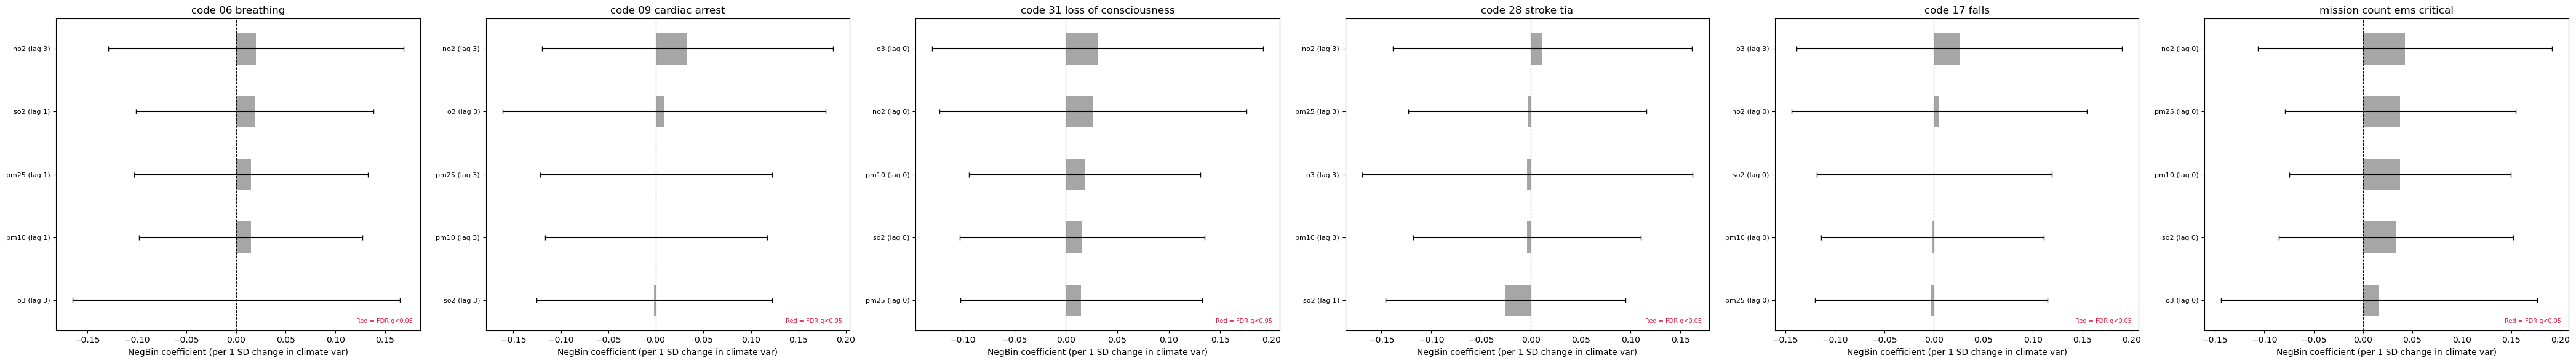

In [10]:
# Forest plot: coefficients for a single outcome across climate vars
def forest_plot(results_df, outcome, ax=None, title=None):
    sub = results_df[results_df['outcome'] == outcome].copy()
    sub = sub.sort_values('coef')
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, max(4, len(sub) * 0.5)))

    colors = ['crimson' if s else 'gray' for s in sub['significant']]
    y_pos  = range(len(sub))

    ax.barh(list(y_pos), sub['coef'], xerr=[
        sub['coef'] - sub['ci_low'],
        sub['ci_high'] - sub['coef']
    ], color=colors, alpha=0.7, height=0.5, capsize=3)
    ax.axvline(0, color='black', lw=0.8, ls='--')
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels([f"{r['climate_var']} (lag {int(r['lag'])})" for _, r in sub.iterrows()], fontsize=8)
    ax.set_xlabel('NegBin coefficient (per 1 SD change in climate var)')
    ax.set_title(title or outcome.replace('_', ' '))
    ax.annotate('Red = FDR q<0.05', xy=(0.98, 0.02), xycoords='axes fraction',
                ha='right', va='bottom', fontsize=7, color='crimson')
    return ax

if 'results_nb' in dir() and len(HEALTH_CODES) > 0:
    # Plot for key outcomes
    key_outcomes = [c for c in ['code_06_breathing','code_09_cardiac_arrest',
                                  'code_31_loss_of_consciousness','code_28_stroke_tia',
                                  'code_17_falls','mission_count_ems_critical']
                    if c in results_nb['outcome'].values]
    if key_outcomes:
        fig, axes = plt.subplots(1, len(key_outcomes),
                                  figsize=(7 * len(key_outcomes), 6))
        if len(key_outcomes) == 1:
            axes = [axes]
        for ax, outcome in zip(axes, key_outcomes):
            forest_plot(results_nb, outcome, ax=ax)
        fig.tight_layout()
        plt.savefig(PROC_DIR / 'negbin_forest_plots.png', dpi=150, bbox_inches='tight')
        plt.show()

## 4. OLS + HAC — Response Time Outcome

Response time is continuous, so we use OLS. HAC (Newey-West) standard errors correct for autocorrelation in residuals without changing coefficient estimates.

In [11]:
def fit_ols_hac(df, outcome, climate_var, lag=0, hac_lags=14, confounders=None):
    """
    Fit OLS with Newey-West HAC standard errors.
    hac_lags: bandwidth for autocorrelation correction (14 days covers 2 weekly cycles).
    Climate var standardised globally (not per-year).
    """
    if confounders is None:
        confounders = ['doy_sin', 'doy_cos', 'day_of_week',
                       'is_public_holiday', 'year']

    work = df[[outcome, climate_var] + confounders].copy()
    work[climate_var] = work[climate_var].shift(lag)
    work = work.dropna()

    cv_std = work[climate_var].std()
    work[climate_var] = (work[climate_var] - work[climate_var].mean()) / cv_std

    y = work[outcome].values
    # Cast to float to avoid dtype=object errors from bool/int mixed columns
    X = add_constant(work[[climate_var] + confounders].astype(float))

    try:
        model    = OLS(y, X).fit()
        cov_hw   = cov_hac(model, nlags=hac_lags)
        hac_se   = np.sqrt(np.diag(cov_hw))
        idx      = list(X.columns).index(climate_var)
        coef     = model.params[climate_var]
        se       = hac_se[idx]
        t_stat   = coef / se
        pval     = 2 * (1 - stats.t.cdf(abs(t_stat), df=len(y) - X.shape[1]))
        return {
            'outcome': outcome, 'climate_var': climate_var, 'lag': lag,
            'coef': coef, 'ci_low': coef - 1.96*se, 'ci_high': coef + 1.96*se,
            'pval': pval, 'r2': model.rsquared, 'n': int(len(y))
        }
    except Exception as e:
        return {'outcome': outcome, 'climate_var': climate_var, 'lag': lag,
                'coef': np.nan, 'ci_low': np.nan, 'ci_high': np.nan,
                'pval': np.nan, 'r2': np.nan, 'n': 0, 'error': str(e)}

if len(RESPONSE_TIME) > 0 and len(PRIMARY_CLIMATE) > 0:
    rt_rows = []
    for outcome in RESPONSE_TIME:
        if outcome not in df.columns:
            continue
        for cv in PRIMARY_CLIMATE:
            result = fit_ols_hac(df, outcome, cv, lag=0, confounders=CONFOUNDERS)
            rt_rows.append(result)

    results_rt = pd.DataFrame(rt_rows)
    _, pvals_fdr, _, _ = multipletests(results_rt['pval'].fillna(1), method='fdr_bh')
    results_rt['pval_fdr'] = pvals_fdr
    results_rt['significant'] = results_rt['pval_fdr'] < 0.05

    print('Response time associations (OLS + HAC):')
    print(results_rt[['climate_var','coef','ci_low','ci_high','pval_fdr','significant']].to_string(index=False))

Response time associations (OLS + HAC):
climate_var     coef    ci_low   ci_high  pval_fdr  significant
       pm25 3.555277  1.396506  5.714048  0.001764         True
       pm10 3.482131  1.574483  5.389780  0.000986         True
        no2 8.014303  3.635705 12.392901  0.000986         True
         o3 0.791276 -2.862687  4.445240  0.671498        False
        so2 4.425509  1.729615  7.121403  0.001764         True


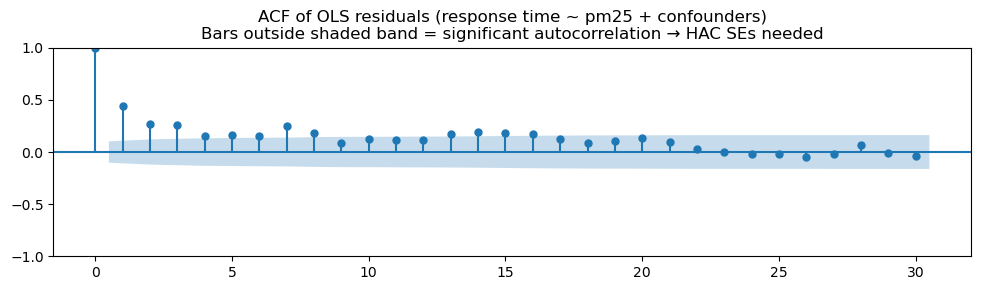

In [12]:
# Residual autocorrelation check — validates that HAC SEs are needed
if len(RESPONSE_TIME) > 0 and 'pm25' in CLIMATE_VARS:
    from statsmodels.graphics.tsaplots import plot_acf

    outcome = RESPONSE_TIME[0]
    work = df[[outcome, 'pm25'] + CONFOUNDERS].dropna()
    X = add_constant(work[['pm25'] + CONFOUNDERS].astype(float))
    resid = OLS(work[outcome].values, X).fit().resid

    fig, ax = plt.subplots(figsize=(10, 3))
    plot_acf(resid, lags=30, ax=ax, alpha=0.05)
    ax.set_title('ACF of OLS residuals (response time ~ pm25 + confounders)\n'
                 'Bars outside shaded band = significant autocorrelation → HAC SEs needed')
    fig.tight_layout()
    plt.savefig(PROC_DIR / 'residual_acf.png', dpi=150, bbox_inches='tight')
    plt.show()

## 5. Distributed Lag Analysis — Temperature → Critical EMS

Fits separate models for each lag (0–7 days) to trace how the effect of temperature builds and decays. The cumulative effect is the sum of coefficients across lags.

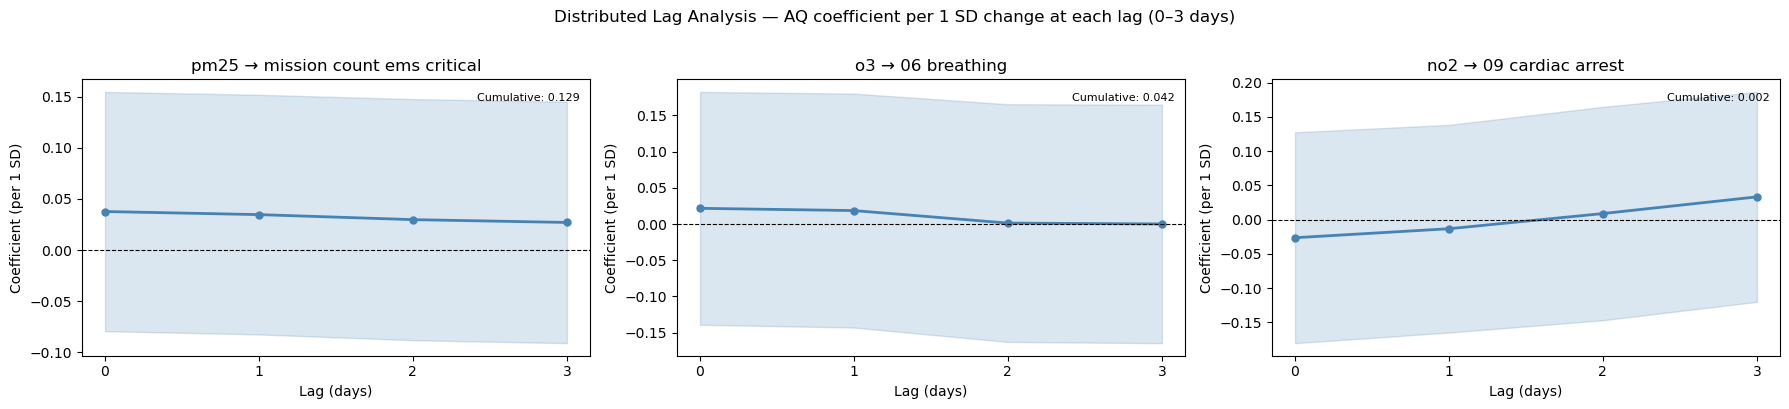

In [13]:
def distributed_lag_plot(df, outcome, climate_var, max_lag=3, ax=None):
    """Fit separate models at each lag 0–max_lag; plot coefficient + 95% CI."""
    lags, coefs, ci_lows, ci_highs = [], [], [], []
    for lag in range(0, max_lag + 1):
        if outcome in AGGREGATE_EMS or outcome in HEALTH_CODES:
            r = fit_negbin(df, outcome, climate_var, lag=lag, confounders=CONFOUNDERS)
        else:
            r = fit_ols_hac(df, outcome, climate_var, lag=lag, confounders=CONFOUNDERS)
        lags.append(lag)
        coefs.append(r['coef'])
        ci_lows.append(r['ci_low'])
        ci_highs.append(r['ci_high'])

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))

    ax.fill_between(lags, ci_lows, ci_highs, alpha=0.2, color='steelblue')
    ax.plot(lags, coefs, 'o-', color='steelblue', lw=2, ms=5)
    ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.set_xlabel('Lag (days)')
    ax.set_ylabel('Coefficient (per 1 SD)')
    ax.set_title(f'{climate_var} → {outcome.replace("code_","").replace("_"," ")}')
    ax.set_xticks(lags)
    cumulative = np.nansum(coefs)
    ax.annotate(f'Cumulative: {cumulative:.3f}', xy=(0.98, 0.95),
                xycoords='axes fraction', ha='right', va='top', fontsize=8)
    return ax

# Key AQ–health pairs for distributed lag analysis (lag 0–3 days)
key_pairs = [
    ('mission_count_ems_critical', 'pm25'),
    ('code_06_breathing',          'o3'),
    ('code_09_cardiac_arrest',     'no2'),
]
key_pairs = [(o, c) for o, c in key_pairs if o in df.columns and c in df.columns]

if key_pairs:
    fig, axes = plt.subplots(1, len(key_pairs), figsize=(6 * len(key_pairs), 4))
    if len(key_pairs) == 1:
        axes = [axes]
    for ax, (outcome, cv) in zip(axes, key_pairs):
        distributed_lag_plot(df, outcome, cv, max_lag=3, ax=ax)
    fig.suptitle('Distributed Lag Analysis — AQ coefficient per 1 SD change at each lag (0–3 days)', y=1.01)
    fig.tight_layout()
    plt.savefig(PROC_DIR / 'distributed_lag.png', dpi=150, bbox_inches='tight')
    plt.show()

## 6. District-Level Fixed Effects Panel

Controls for unobserved time-invariant district characteristics (population density, green space, income) via district fixed effects.

In [14]:
dist_path = PROC_DIR / 'daily_district_health.csv'
if not dist_path.exists():
    print('District data not found — run notebook 02 first')
else:
    dist_df = pd.read_csv(dist_path, parse_dates=['date'])
    print(f'District panel: {dist_df.shape}')
    print(f'Districts: {dist_df.district.nunique()}')

District panel: (36600, 24)
Districts: 12


In [15]:
# ── District panel: use per-district CAMS values (already interpolated to district centroids)
dist_cams_path = PROC_DIR / 'cams_daily_district_2025.csv'
dist_health_path = PROC_DIR / 'daily_district_health.csv'

if dist_cams_path.exists() and dist_health_path.exists():
    dist_health = pd.read_csv(dist_health_path, parse_dates=['date'])
    dist_health = dist_health[dist_health['date'].dt.year == 2025].reset_index(drop=True)

    dist_cams = pd.read_csv(dist_cams_path, parse_dates=['date'])

    dist_merged = dist_health.merge(
        dist_cams[['date', 'district'] + PRIMARY_CLIMATE],
        on=['date', 'district'], how='inner'
    )
    print(f'District panel: {dist_merged.shape}')
    print(f'Districts: {dist_merged["district"].nunique()}')
    print(f'Date range: {dist_merged.date.min().date()} → {dist_merged.date.max().date()}')
else:
    print('District CAMS file not found — run src/preprocess_cams_2025.py first')

District panel: (4380, 29)
Districts: 12
Date range: 2025-01-01 → 2025-12-31


In [16]:
# Fixed-effects panel regression: outcome ~ AQ_var + confounders + district_dummies
def fit_panel_fe(panel_df, outcome, climate_var, lag=0, confounders=None):
    if confounders is None:
        confounders = ['doy_sin', 'doy_cos', 'day_of_week', 'is_public_holiday', 'year']

    work = panel_df[['date', 'district', outcome, climate_var] + confounders].copy()
    work[climate_var] = work.groupby('district')[climate_var].shift(lag)
    work = work.dropna()

    # Global standardisation across all districts and years
    cv_std = work[climate_var].std()
    work[climate_var] = (work[climate_var] - work[climate_var].mean()) / cv_std

    district_dummies = pd.get_dummies(work['district'], drop_first=True, prefix='d')
    X = add_constant(pd.concat([
        work[[climate_var] + confounders],
        district_dummies
    ], axis=1).astype(float))
    y = work[outcome].values

    try:
        model  = OLS(y, X).fit()
        cov_hw = cov_hac(model, nlags=14)
        se     = np.sqrt(np.diag(cov_hw))[list(X.columns).index(climate_var)]
        coef   = model.params[climate_var]
        t      = coef / se
        pval   = 2 * (1 - stats.t.cdf(abs(t), df=len(y) - X.shape[1]))
        return {'outcome': outcome, 'climate_var': climate_var, 'lag': lag,
                'coef': coef, 'se_hac': se,
                'ci_low': coef - 1.96*se, 'ci_high': coef + 1.96*se,
                'pval': pval, 'r2': model.rsquared, 'n': int(len(y))}
    except Exception as e:
        return {'outcome': outcome, 'climate_var': climate_var, 'lag': lag,
                'coef': np.nan, 'pval': np.nan, 'error': str(e)}

if 'dist_merged' in dir() and len(PRIMARY_CLIMATE) > 0:
    panel_results = []
    dist_outcomes = [c for c in ['code_06_breathing', 'code_17_falls',
                                  'code_31_loss_of_consciousness', 'code_09_cardiac_arrest']
                     if c in dist_merged.columns]
    for outcome in dist_outcomes:
        for cv in PRIMARY_CLIMATE[:3]:  # pm25, pm10, no2
            if cv not in dist_merged.columns:
                continue
            r = fit_panel_fe(dist_merged, outcome, cv, lag=0, confounders=CONFOUNDERS)
            panel_results.append(r)

    panel_df_res = pd.DataFrame(panel_results)
    _, pvals_fdr, _, _ = multipletests(panel_df_res['pval'].fillna(1), method='fdr_bh')
    panel_df_res['pval_fdr'] = pvals_fdr
    panel_df_res['significant'] = panel_df_res['pval_fdr'] < 0.05
    print('Panel fixed-effects results:')
    print(panel_df_res[['outcome','climate_var','coef','ci_low','ci_high','pval_fdr','significant']].to_string(index=False))

Panel fixed-effects results:
                      outcome climate_var      coef    ci_low  ci_high  pval_fdr  significant
            code_06_breathing        pm25  0.120992 -0.081643 0.323626  0.580663        False
            code_06_breathing        pm10  0.138700 -0.054103 0.331504  0.475835        False
            code_06_breathing         no2 -0.032609 -0.214767 0.149549  0.854064        False
                code_17_falls        pm25 -0.056293 -0.300552 0.187965  0.854064        False
                code_17_falls        pm10 -0.032702 -0.257947 0.192544  0.854064        False
                code_17_falls         no2  0.064574 -0.249803 0.378951  0.854064        False
code_31_loss_of_consciousness        pm25  0.167835 -0.018905 0.354574  0.312846        False
code_31_loss_of_consciousness        pm10  0.208970  0.021872 0.396069  0.171845        False
code_31_loss_of_consciousness         no2  0.258858  0.060479 0.457237  0.126901        False
       code_09_cardiac_arrest  

## 7. Save Results

In [17]:
if 'results_nb' in dir():
    results_nb.to_csv(PROC_DIR / 'results_negbin.csv', index=False)
    print(f'Saved: results_negbin.csv ({len(results_nb)} rows)')

if 'results_rt' in dir():
    results_rt.to_csv(PROC_DIR / 'results_ols_hac.csv', index=False)
    print(f'Saved: results_ols_hac.csv ({len(results_rt)} rows)')

if 'panel_df_res' in dir():
    panel_df_res.to_csv(PROC_DIR / 'results_panel_fe.csv', index=False)
    print(f'Saved: results_panel_fe.csv ({len(panel_df_res)} rows)')

Saved: results_negbin.csv (75 rows)
Saved: results_ols_hac.csv (5 rows)
Saved: results_panel_fe.csv (12 rows)


## 8. Null Model Comparison

Validation: does adding climate variables improve fit over the seasonal-only baseline?

In [18]:
if len(HEALTH_CODES) > 0 and 'pm25' in CLIMATE_VARS:
    outcome = 'mission_count_ems_critical' if 'mission_count_ems_critical' in df.columns else HEALTH_CODES[0]
    work = df[[outcome, 'pm25'] + CONFOUNDERS].dropna()
    y = work[outcome].values

    # Null model: seasonal + confounders only (no AQ)
    X_null = add_constant(work[CONFOUNDERS].astype(float))
    null_model = GLM(y, X_null, family=families.NegativeBinomial()).fit(disp=False)

    # Full model: + pm25
    X_full = add_constant(work[['pm25'] + CONFOUNDERS].astype(float))
    full_model = GLM(y, X_full, family=families.NegativeBinomial()).fit(disp=False)

    print(f'Outcome: {outcome}')
    print(f'Null model AIC (confounders only): {null_model.aic:.1f}')
    print(f'Full model AIC (+pm25)           : {full_model.aic:.1f}')
    delta_aic = null_model.aic - full_model.aic
    print(f'ΔAIC (positive = AQ adds value)  : {delta_aic:.1f}')
    if delta_aic > 2:
        print('→ PM2.5 significantly improves fit over the seasonal baseline (ΔAIC > 2)')
    else:
        print('→ PM2.5 does NOT meaningfully improve fit — consider whether confounders are sufficient')

Outcome: mission_count_ems_critical
Null model AIC (confounders only): 5695.1
Full model AIC (+pm25)           : 5696.7
ΔAIC (positive = AQ adds value)  : -1.6
→ PM2.5 does NOT meaningfully improve fit — consider whether confounders are sufficient
